# 02 – RL Agent Training (Fair PPO + CNN)

Human-fair training: `PacmanGridEnv` obserwacja `9×31×28` (ściany, kropki, duchy, owoc, życia HUD, **poziom**),
**bez action masks** i **bez PBRS**. Algorytm **PPO** z siecią `PacmanCNN`, curriculum 2-fazowy.

Headless: `python scripts/train_ppo_fair.py --fresh-start`

Logowanie tekstowe co `LOG_EVERY` kroków + metryki PPO loss do MLflow. Eval na seedach 100–103 co `EVAL_EVERY`.
Wykresy: `python scripts/plot_training.py` → `reports/training_dashboard.png`, `training_loss_dashboard.png`.

Naciśnij **Stop**, aby przerwać; checkpoint zapisywany co `CHECKPOINT_EVERY` kroków.

In [1]:
# Install sb3-contrib into THIS kernel (idempotent; %pip ensures correct interpreter).
import importlib, subprocess, sys
if importlib.util.find_spec("sb3_contrib") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "sb3-contrib"])
    print("sb3-contrib installed — restart NOT required, just re-run the next cell.")
else:
    print("sb3-contrib already available.")

sb3-contrib already available.


In [1]:
import sys, os, shutil
sys.path.insert(0, '..')

import torch
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import SubprocVecEnv, DummyVecEnv, VecMonitor, VecFrameStack

from src.environment.pacman_env import PacmanGridEnv
from src.utils.lr_schedule import constant_schedule, linear_schedule
from src.utils.maskable_env import (
    create_maskable_ppo, load_trainable_model, wrap_with_action_masker, predict_action,
)
from src.utils.mlflow_logger import MLflowLogger
from src.utils.ppo_cnn import policy_kwargs
from src.utils.training_callbacks import ConsoleCallback
from src.utils.obs_sync import include_flags_from_checkpoint, peek_checkpoint, validate_model_env

_EPISODE_INFO_KEYS = (
    'score', 'level', 'pellet_completion',
    'episode_deaths', 'max_level_reached', 'level_clears',
)

In [3]:
print(torch.cuda.is_available())

True


In [2]:
# ── Configuration ────────────────────────────────────────────────────────────
N_ENVS            = 8
N_STEPS           = 512
N_STACK           = 4
PHASE1_STEPS      = 1_000_000
PHASE2_STEPS      = 4_000_000
ADDITIONAL_STEPS  = 2_000_000   # resume: train THIS MANY MORE steps
CHECKPOINT_PATH   = os.path.join('..', 'models', 'ppo_pacman')
CHECKPOINT_EVERY  = 100_000
LOG_EVERY         = 10_000
EVAL_EVERY        = 100_000
FRESH_START       = False
USE_MASKABLE      = True        # MaskablePPO + action masks (recommended)
LR_SCHEDULE       = 'constant'  # avoids LR→0 on long resume segments
LEARNING_RATE     = 1e-4
ENT_COEF_PHASE1   = 0.02
ENT_COEF_PHASE2   = 0.02
TB_LOG            = os.path.join('..', 'logs', 'tensorboard')

INCLUDE_COMPLETION_PLANE = FRESH_START
INCLUDE_FRIGHTENED_PLANE = FRESH_START
EASY_ENDGAME = FRESH_START

def make_env(seed: int, max_steps: int):
    def _f():
        env = PacmanGridEnv(
            seed=seed, max_steps=max_steps,
            step_penalty=-0.0005, reward_scale_div=50.0,
            death_penalty=-3.0, level_bonus=5000.0,
            endgame_death_surcharge=-3.0,
            idle_penalty=-0.02, wasted_power_penalty=-1.5,
            near_miss_penalty=-5.0, enable_milestones=True,
            pbrs_coef=0.0, human_fair=True,
            include_completion_plane=INCLUDE_COMPLETION_PLANE,
            include_frightened_plane=INCLUDE_FRIGHTENED_PLANE,
            easy_endgame=EASY_ENDGAME,
        )
        if USE_MASKABLE:
            env = wrap_with_action_masker(env)
        return Monitor(env, info_keywords=_EPISODE_INFO_KEYS)
    return _f

def build_vec(max_steps: int):
    fns = [make_env(seed=i, max_steps=max_steps) for i in range(N_ENVS)]
    v = DummyVecEnv(fns) if os.name == 'nt' else SubprocVecEnv(fns)
    v = VecMonitor(v)
    return VecFrameStack(v, n_stack=N_STACK, channels_order='first')

_lr_fn = constant_schedule(LEARNING_RATE) if LR_SCHEDULE == 'constant' else linear_schedule(LEARNING_RATE)

models_dir = os.path.join('..', 'models')
checkpoint_zip = CHECKPOINT_PATH + '.zip'
if FRESH_START and os.path.isdir(models_dir):
    removed = 0
    for root, _, files in os.walk(models_dir):
        for f in files:
            if f.endswith('.zip'):
                os.remove(os.path.join(root, f))
                removed += 1
    print(f'[Fresh start] removed {removed} checkpoint(s)')

resuming = os.path.exists(checkpoint_zip) and not FRESH_START
model = None

if resuming:
    INCLUDE_COMPLETION_PLANE, INCLUDE_FRIGHTENED_PLANE = include_flags_from_checkpoint(
        checkpoint_zip, N_STACK
    )
    EASY_ENDGAME = False
    peek = peek_checkpoint(CHECKPOINT_PATH, device='auto')
    start_steps = int(peek.num_timesteps)
    del peek
    max_steps_env = 8000 if start_steps >= PHASE1_STEPS else 2500
    target_timesteps = start_steps + ADDITIONAL_STEPS
    vec_env = build_vec(max_steps_env)
    model = load_trainable_model(
        CHECKPOINT_PATH, vec_env, use_maskable=USE_MASKABLE, device='auto',
        create_kwargs=dict(
            learning_rate=_lr_fn, n_steps=N_STEPS, batch_size=512,
            ent_coef=ENT_COEF_PHASE1, device='auto', tensorboard_log=TB_LOG,
        ),
    )
    print(
        f'[Resume] checkpoint @ {start_steps:,} | maskable={USE_MASKABLE} | '
        f'completion={INCLUDE_COMPLETION_PLANE} frightened={INCLUDE_FRIGHTENED_PLANE}'
    )
else:
    start_steps = 0
    max_steps_env = 2500
    target_timesteps = PHASE1_STEPS + PHASE2_STEPS
    ch = 9 + int(INCLUDE_COMPLETION_PLANE) + int(INCLUDE_FRIGHTENED_PLANE)
    algo = 'MaskablePPO' if USE_MASKABLE else 'PPO'
    print(f'[Initial run] {algo} + PacmanCNN ({ch}ch × stack {N_STACK})')

vec_env = build_vec(max_steps_env)

if model is None:
    if USE_MASKABLE:
        model = create_maskable_ppo(
            vec_env, learning_rate=_lr_fn, n_steps=N_STEPS, batch_size=512,
            ent_coef=ENT_COEF_PHASE1, device='auto', tensorboard_log=TB_LOG,
        )
    else:
        model = PPO(
            'CnnPolicy', vec_env, learning_rate=_lr_fn, n_steps=N_STEPS,
            batch_size=512, n_epochs=4, gamma=0.995, gae_lambda=0.95,
            clip_range=0.2, ent_coef=ENT_COEF_PHASE1,
            vf_coef=0.5, max_grad_norm=0.5,
            policy_kwargs=policy_kwargs(), verbose=0, device='auto',
            tensorboard_log=TB_LOG,
        )
else:
    model.set_env(vec_env)
    model.ent_coef = max(ENT_COEF_PHASE2, float(model.ent_coef))

validate_model_env(model, vec_env, context='notebook cell 4')
print(f'Obs: {vec_env.observation_space.shape} | model: {model.observation_space.shape} | target={target_timesteps:,}')

c:\Users\oliwi\AppData\Local\Programs\Python\Python311\Lib\site-packages\stable_baselines3\common\vec_env\vec_monitor.py:43: UserWarning: The environment is already wrapped with a `Monitor` wrapperbut you are wrapping it with a `VecMonitor` wrapper, the `Monitor` statistics will beoverwritten by the `VecMonitor` ones.
  warnings.warn(


[Resume] checkpoint @ 25,757,432 | maskable=True | completion=True frightened=True
Obs: (44, 31, 28) | model: (44, 31, 28) | target=27,757,432


## Training loop (2-phase curriculum)

Phase 1: `max_steps=2500`, `ent_coef=0.02`. Phase 2: multi-level, `max_steps=8000`, `ent_coef=0.005`.
Reward = Δscore/50 − 3·death − 0.0005/krok (+20 za level clear). LR maleje liniowo 2.5e-4 → 0.
Held-out eval (seeds 100–103) co `EVAL_EVERY` kroków.

In [3]:
print(f'Training — MaskablePPO={USE_MASKABLE} | resume_from={start_steps:,} | target={target_timesteps:,}\n')

with MLflowLogger(experiment_name='rl_training', run_name='ppo_fair_cnn') as logger:
    logger.log_params({
        'algorithm': 'MaskablePPO' if USE_MASKABLE else 'PPO',
        'n_envs': N_ENVS, 'n_stack': N_STACK, 'resume_from': start_steps,
        'target_timesteps': target_timesteps, 'gamma': 0.995,
        'learning_rate': LEARNING_RATE, 'lr_schedule': LR_SCHEDULE,
        'ent_coef_phase1': ENT_COEF_PHASE1, 'ent_coef_phase2': ENT_COEF_PHASE2,
        'ent_plateau_pellet_threshold': 0.75,
        'include_completion_plane': INCLUDE_COMPLETION_PLANE,
        'include_frightened_plane': INCLUDE_FRIGHTENED_PLANE,
        'action_masks': USE_MASKABLE, 'eval_every': EVAL_EVERY,
    })

    callback = ConsoleCallback(
        CHECKPOINT_PATH, CHECKPOINT_EVERY, LOG_EVERY, logger,
        target_timesteps=target_timesteps, resume_from=start_steps,
        eval_every=EVAL_EVERY, n_stack=N_STACK,
        include_completion_plane=INCLUDE_COMPLETION_PLANE,
        include_frightened_plane=INCLUDE_FRIGHTENED_PLANE,
        use_action_masks=USE_MASKABLE,
        ent_coef_normal=ENT_COEF_PHASE2,
    )

    run_phase1 = (not resuming) and (PHASE1_STEPS > 0) and (model.num_timesteps < PHASE1_STEPS)

    if run_phase1:
        validate_model_env(model, model.get_env(), context='before phase 1 learn')
        try:
            print(f'=== Phase 1 -> {PHASE1_STEPS:,} steps ===')
            model.learn(total_timesteps=PHASE1_STEPS, callback=callback,
                        reset_num_timesteps=True, progress_bar=False)
        except KeyboardInterrupt:
            print('\nPhase 1 interrupted.')
        vec_env.close()
        vec_env2 = build_vec(max_steps=8000)
        validate_model_env(model, vec_env2, context='before phase 2 set_env')
        model.set_env(vec_env2)
        model.ent_coef = ENT_COEF_PHASE2

    try:
        remaining = max(0, target_timesteps - int(model.num_timesteps))
        print(f'\n=== Training until {target_timesteps:,} steps (+{remaining:,} remaining) ===')
        if remaining > 0:
            model.learn(total_timesteps=remaining, callback=callback,
                        reset_num_timesteps=False, progress_bar=False)
    except KeyboardInterrupt:
        print('\nTraining interrupted.')
    finally:
        model.save(CHECKPOINT_PATH)
        logger.log_metrics({'total_timesteps': model.num_timesteps})
        training_history = callback.history()
        print(f'\nSaved -> {CHECKPOINT_PATH}.zip @ {model.num_timesteps:,} steps')

Training — MaskablePPO=True | resume_from=25,741,048 | target=27,741,048


=== Training until 27,741,048 steps (+2,000,000 remaining) ===

--------------------------------------------------------------
  Pac-Man PPO  |  step 25,750,000 / 27,741,048  |    0.2 min  |    706 fps
--------------------------------------------------------------
  Episodes (50):  return   77.88  |  score    4590  (scaled  91.8)  |  gap -13.92
  Progress:       level 1.00  |  max_lvl 1.00  |  clears  0.0%  |  pellets  72.3%
  Survival:       length   383  |  deaths/ep 3.10  |  total eps 20
  Shaping:        milestone_r  0.00  |  ent_coef 0.0200
  PPO loss:       loss=14.8845  |  value_loss=39.6118  |  entropy_loss=-0.4200
--------------------------------------------------------------

Training interrupted.

Saved -> ..\models\ppo_pacman.zip @ 25,757,432 steps


## 🎬 Test and Watch the Trained Agent in Action!

Once you believe your agent is trained enough (when its average reward starts climbing and stabilizing), run the cell below to **watch the agent play Pac-Man in real-time** via an ASCII live-render animation!

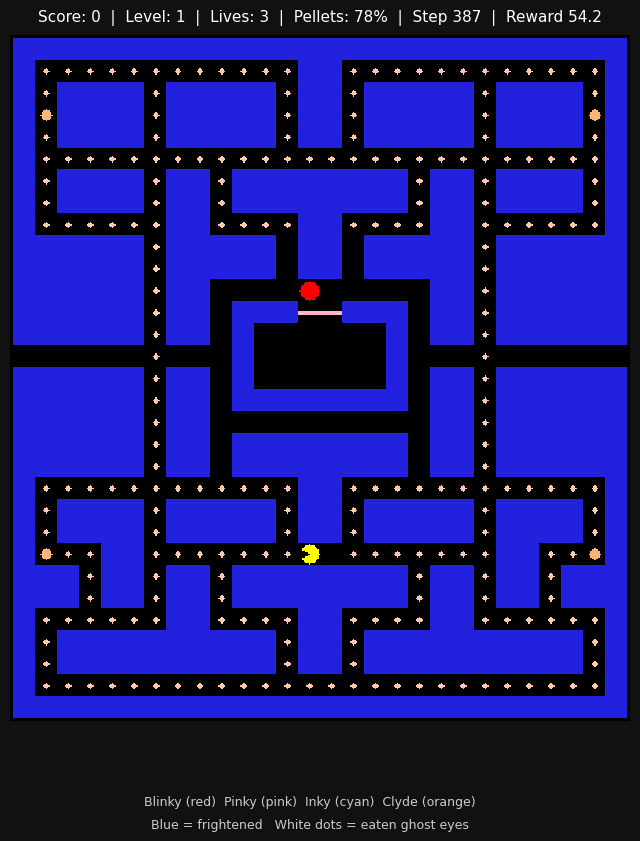

Game Over!


In [3]:
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
from src.utils.pacman_renderer import render_state_rgb, render_hud_text, ghost_legend_lines
import time

print('Loading trained model...')
checkpoint_zip = CHECKPOINT_PATH + '.zip'
_play_inc_c, _play_inc_f = include_flags_from_checkpoint(checkpoint_zip, N_STACK)
raw_env = PacmanGridEnv(
    seed=42, human_fair=True, render_mode='rgb_array',
    include_completion_plane=_play_inc_c,
    include_frightened_plane=_play_inc_f,
)
if USE_MASKABLE:
    raw_env = wrap_with_action_masker(raw_env)
eval_venv = VecFrameStack(
    DummyVecEnv([lambda: Monitor(raw_env)]), n_stack=N_STACK, channels_order='first'
)
trained_model = load_trainable_model(
    CHECKPOINT_PATH, eval_venv, use_maskable=USE_MASKABLE, device='auto',
    create_kwargs=dict(
        learning_rate=1e-4, n_steps=N_STEPS, batch_size=512,
        ent_coef=0.02, device='auto', tensorboard_log=None,
    ),
)
validate_model_env(trained_model, eval_venv, context='play demo')
print(f'Model obs {trained_model.observation_space.shape} | env obs {eval_venv.observation_space.shape}')
obs = eval_venv.reset()
done = False
total_eval_reward = 0.0
step_num = 0

fig, ax = plt.subplots(figsize=(8, 9), facecolor='#111')
plt.close(fig)

def _unwrap_grid(venv):
    e = venv.envs[0]
    while hasattr(e, 'env'):
        e = e.env
    return e

while not done:
    action, _ = predict_action(trained_model, obs, eval_venv, deterministic=True)
    obs, rewards, dones, infos = eval_venv.step(action)
    total_eval_reward += float(rewards[0])
    done = bool(dones[0])
    info = infos[0]
    step_num += 1

    st = _unwrap_grid(eval_venv)._state
    frame = render_state_rgb(st, cell_size=16)
    clear_output(wait=True)

    fig, ax = plt.subplots(figsize=(8, 9), facecolor='#111')
    ax.imshow(frame, interpolation='nearest')
    ax.axis('off')
    title = (
        f"{render_hud_text(st, info)}  |  Step {step_num}  |  "
        f"Reward {total_eval_reward:.1f}"
    )
    ax.set_title(title, color='white', fontsize=11, pad=10)
    for i, line in enumerate(ghost_legend_lines()):
        fig.text(0.5, 0.02 - i * 0.025, line, ha='center', color='#ccc', fontsize=9)
    display(fig)
    plt.close(fig)
    time.sleep(0.06)

print('Game Over!')
